In [239]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [240]:
f = lambda x: 3*x**2 - 4*x + 5

In [241]:
f(3.0)

20.0

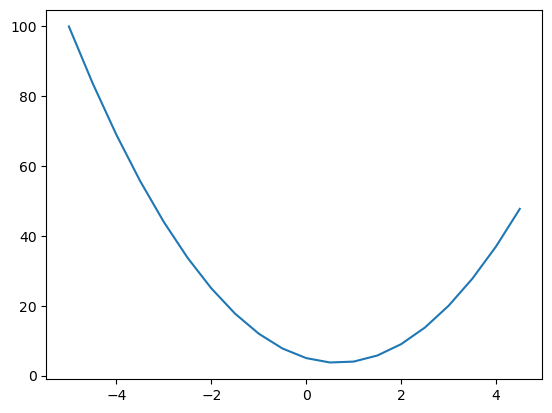

In [242]:
xs = np.arange(-5,5,0.5)
ys = f(xs)
plt.plot(xs,ys)

In [243]:
h = 0.001
x = 3.0
(f(x+h) - f(x))/h

14.00300000000243

In [244]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev =set(_children)
        self._op = _op
        self.label=label
    
    def __repr__(self): return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data+other.data, (self, other), "+")
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __neg__(self): return self * -1

    def __sub__(self, other): return self + (-other)
    
    def __rsub__(self, other): return self - other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data*other.data, (self, other), "*")
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    
    def __rmul__(self, other):
        return self * other
    

    
    def __truediv__(self, other): #self/other
        return self*other**-1
    
    def __pow__(self, other): #self**pow
        assert isinstance(other, (int, float)), "only support int/float powers"
        out = Value(self.data**other, (self,), f"**{other}")
        def _backward():
            self.grad += out.grad * other * self.data**(other-1)
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out =  Value(t, (self, ), 'tanh')
        def _backward():
            self.grad = (1-t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e+c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

In [245]:
L._prev

{Value(data=-2.0), Value(data=4.0)}

In [246]:
L._op

'*'

In [247]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label=f"{n.label} | data {n.data:4f} | grad {n.grad:4f}", shape="record")
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

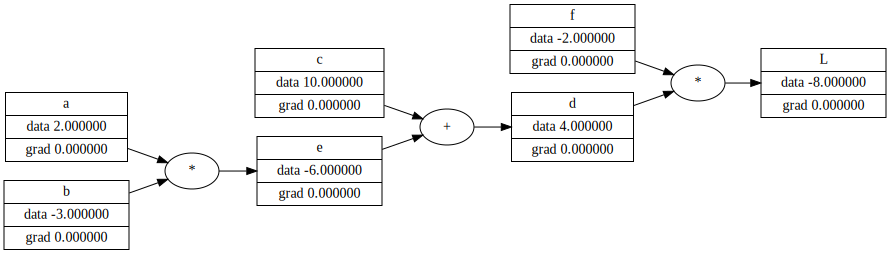

In [248]:
draw_dot(L)

In [249]:
def lol():
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L1 = L.data

    a = Value(2.0+h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L2 = L.data

    print((L2-L1)/h)
lol()

6.000000000000227


In [250]:
L.grad = 1.0

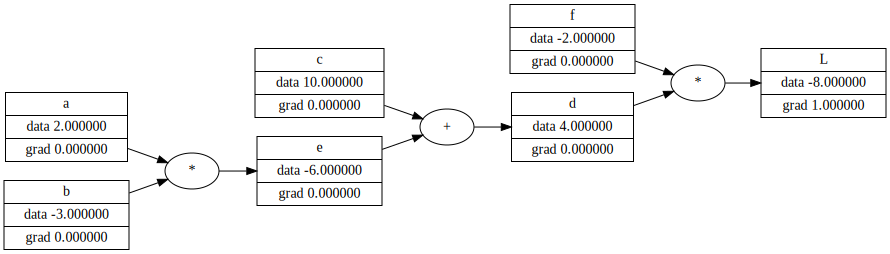

In [251]:
draw_dot(L)

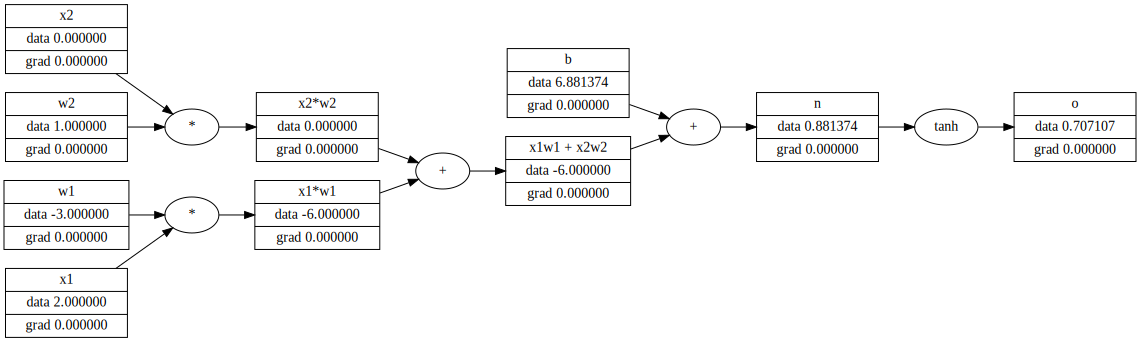

In [252]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias
b = Value(6.8813735870195432, label="b")
x1w1 = x1 * w1; x1w1.label="x1*w1"
x2w2 = x2 * w2; x2w2.label="x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'
draw_dot(o)

In [253]:
o.grad = 1.0
o._backward()

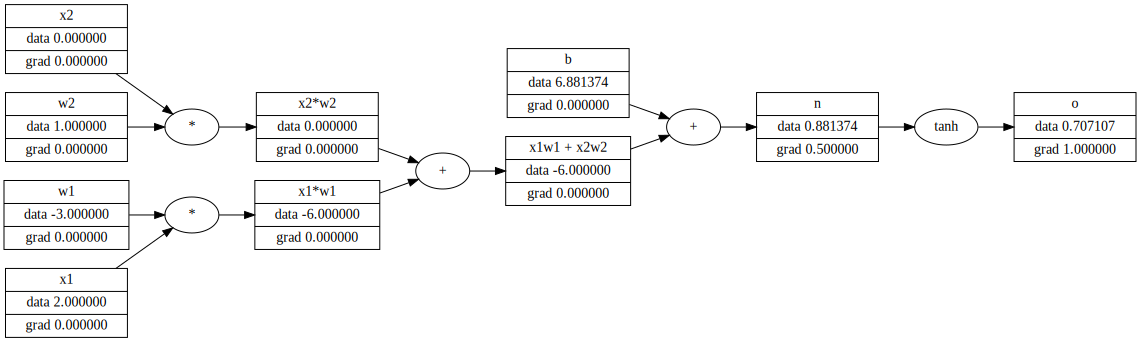

In [254]:
draw_dot(o)

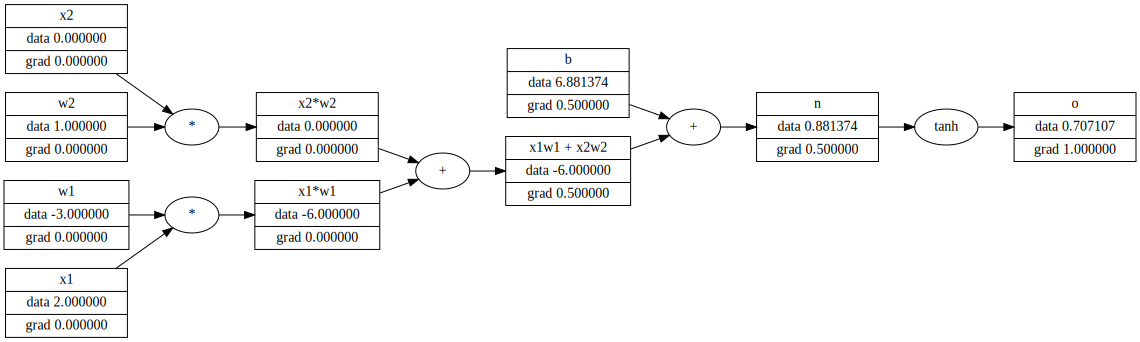

In [255]:
n._backward()
draw_dot(o)

In [256]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

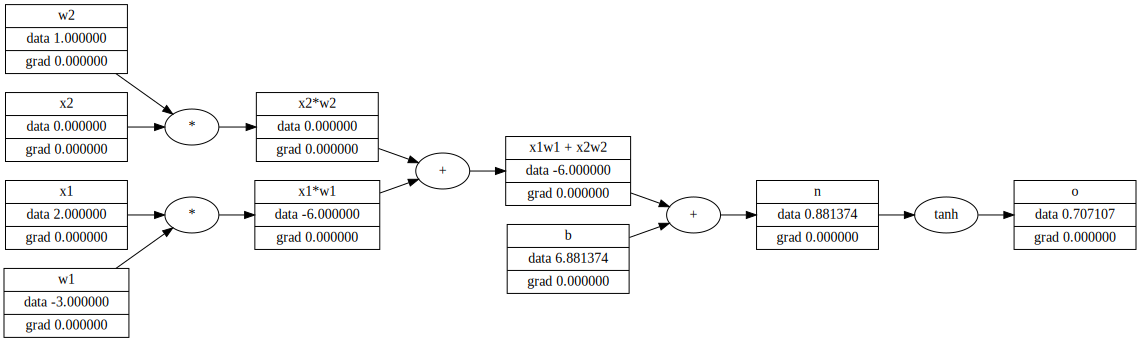

In [257]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias
b = Value(6.8813735870195432, label="b")
x1w1 = x1 * w1; x1w1.label="x1*w1"
x2w2 = x2 * w2; x2w2.label="x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'
draw_dot(o)

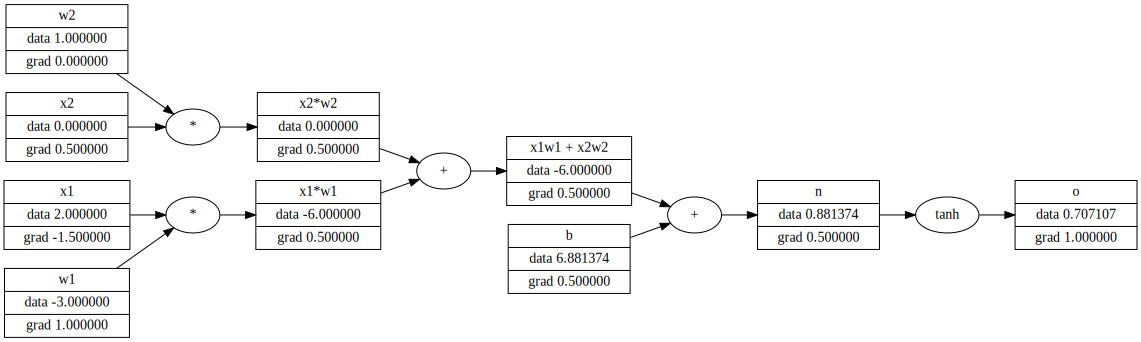

In [258]:

o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)

for node in reversed(topo):
    node._backward()
draw_dot(o)

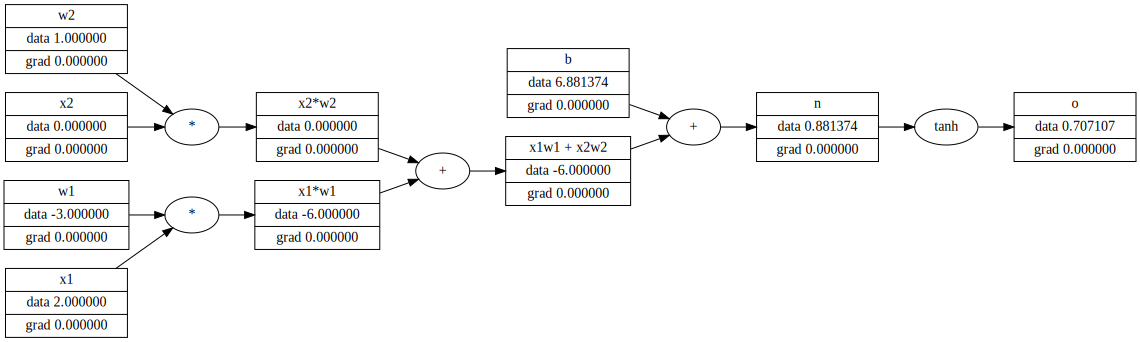

In [259]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias
b = Value(6.8813735870195432, label="b")
x1w1 = x1 * w1; x1w1.label="x1*w1"
x2w2 = x2 * w2; x2w2.label="x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'
draw_dot(o)

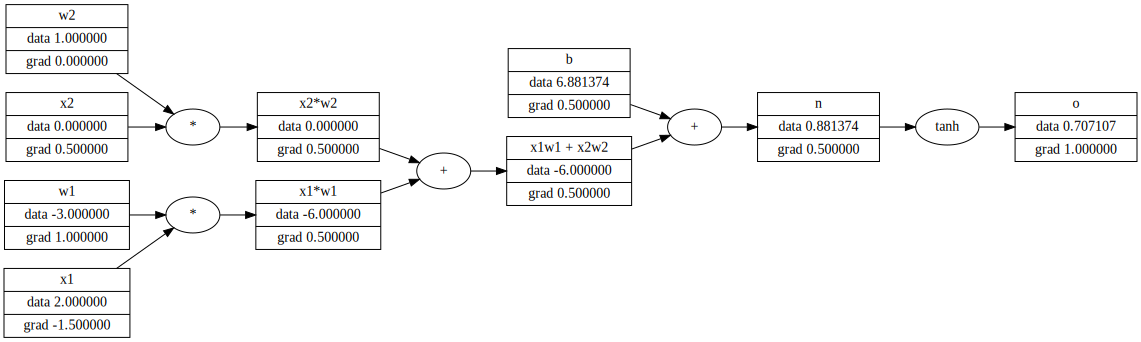

In [260]:
o.backward()
draw_dot(o)

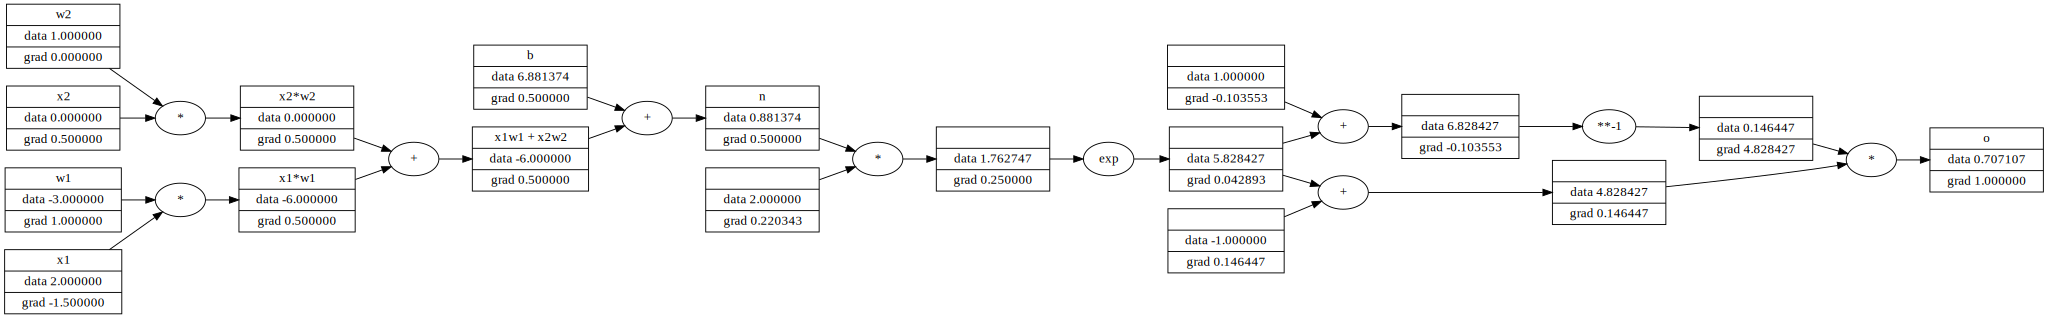

In [261]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias
b = Value(6.8813735870195432, label="b")
x1w1 = x1 * w1; x1w1.label="x1*w1"
x2w2 = x2 * w2; x2w2.label="x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label='n'
# --
e = (2*n).exp()
o = (e-1)/(e+1); o.label='o'
o.backward()
draw_dot(o)

In [262]:
import random

class Neuron:
    def __init__(self, nin): # number inputs
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        #res = sum(wi*xi for wi,xi in zip(self.w, x)) + self.b
        res = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        out = res.tanh()
        return out
    
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=-0.6403305067392808)

In [272]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        #return outs
        return outs[0] if len(outs)==1 else outs

x = [2.0, 3.0]
n = Layer(2, 5)
n(x)

[Value(data=-0.19401753275773923),
 Value(data=0.9884865413520987),
 Value(data=0.6079178119768575),
 Value(data=0.5601236181987893),
 Value(data=-0.9588706633859211)]

In [275]:
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
x = [2.0, 3.0, -1.0]
n = MLP(3, [3,5,1])
n(x)

Value(data=0.12243693019759976)

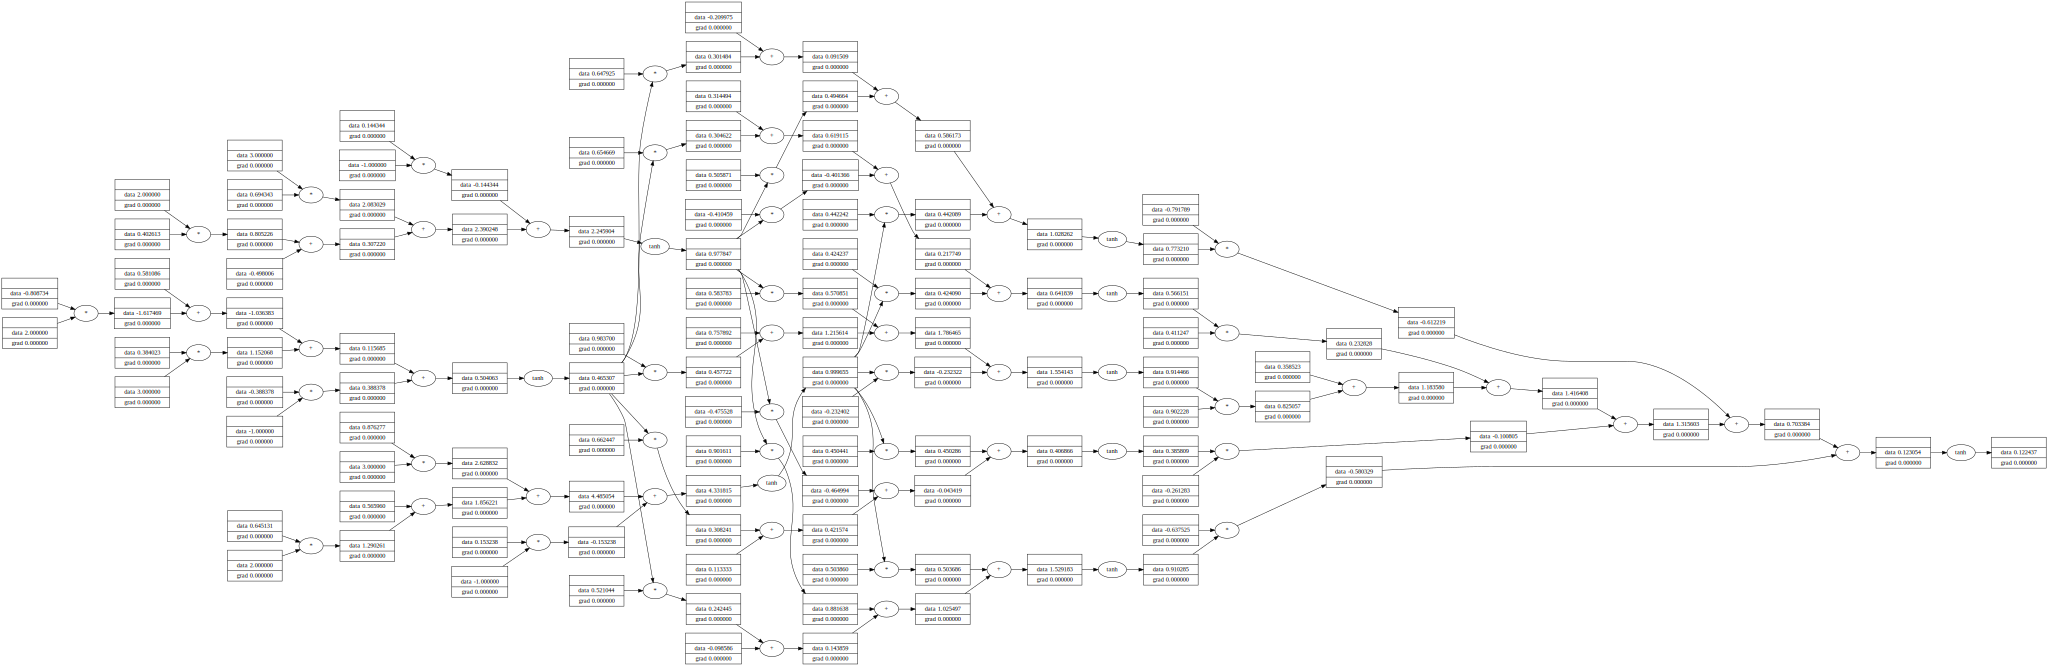

In [276]:
draw_dot(n(x))

In [277]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.12243693019759976),
 Value(data=0.3974219750448636),
 Value(data=0.28643103107826),
 Value(data=0.2625139630801998)]

In [280]:
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=4.921695570192048)

In [281]:
loss.backward()

In [288]:
n.layers[0].neurons[0].w[2].grad

-0.5548901546497572